# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

Which pages in a content catalog are worth prioritizing for a refresh, and what should
an editor do first? The decision this supports: a content team has limited time, and
needs a ranked, explainable shortlist of pages to review — not a blanket "refresh
everything" or "refresh nothing" call.

This work builds a rule-based baseline (a tiered gate + weighted scoring formula) and
tests whether a learned model, using only the same tier-specific signals, can
reproduce the baseline's priority ordering without ever seeing the signals that
actually define eligibility for a refresh.

## 2. Data

Source: the full FlyRank internship warehouse release (Hugging Face,
`FlyRank/internship-warehouse`), specifically `fact_content_daily_performance` for
February and March 2026 (client × content × day grain, aggregated to one row per
page for this work).

Excluded, and why:
- `fact_content_query_90d` — its 90-day window is fixed to the sealed test period
  (April-June 2026), so it cannot be used without leaking that period into training.
- `dim_content`'s date columns (`content_updated_date`, `last_optimized_date`,
  `optimization_eligible_date`) — these are current-state snapshots as of a later
  export date, not historical values, so using them would leak future information.
- `trend_pct` / `trend_direction` — used only to build the eligibility gate and label,
  never as a model feature, to avoid the model trivially reproducing its own label.

No client names, domains, or private queries appear anywhere in this work;
`client_hash_id` / `content_hash_id` are used only for grouping (train/test splits),
never as model features.

## 3. Methodology

Pages are routed into one of three tiers based on data availability (GSC only, GA4
only, or both — "Full"), since each tier has a different set of usable signals.

Each tier has its own two-part design:
- A **gate**, built from thresholds on 1-2 signals independent of that tier's scoring
  signals (e.g. Full tier: month-over-month search impression decline + a
  within-client percentile check on GA4 sessions). The gate's output directly defines
  the `needs_refresh` label — there is no separate, hand-labeled ground truth.
- A **baseline score**: a hand-picked, SEO-reasoned weighted formula over that tier's
  remaining signals (CTR, position, engagement rate, etc.), producing a priority
  ranking among eligible pages.

Several thresholds are grounded in external research rather than personal judgment or
this dataset's own distribution — specifically, the ±15%/±50% trend-severity bands,
the expected-CTR-by-position curve, and the ~50% GA4 engagement-rate cutoff were each
based on a search of published SEO/GA4 benchmark sources, disclosed at the point they
are used, rather than presented as this project's own findings. Where no external
benchmark existed or applied cleanly (e.g. scroll rate, which is not the same metric
as commonly-benchmarked scroll depth), a within-population threshold is used instead
and labeled as relative, not standard.

The model is a pairwise learning-to-rank approach: for pairs of pages within the same
client, the difference between their feature vectors is used to predict which of the
two the baseline formula ranked higher, via Logistic Regression. This directly targets
the baseline's *ranking*, not an arbitrary score value, and only uses the same
signals available to the baseline's scoring formula — never the gate signals, to keep
the comparison meaningful rather than circular.

Leakage was checked directly in two ways: (1) an earlier experiment (Week 3) showed
that including a gate-derived signal as a model feature inflated performance to near-
perfect, demonstrating the leak concretely; the final design excludes any such signal
from every tier's feature set. (2) The validation split is grouped by
`client_hash_id` (`GroupShuffleSplit`), so no client's pages appear in both train and
test — preventing the model from learning client-specific shortcuts instead of the
general signal relationships being tested.

**AI assistance disclosure**: this project was built with Claude as a coding and
design-reasoning assistant throughout — reviewing code for bugs, proposing
implementation approaches, and searching for external benchmarks on request. All
domain decisions (which signals to use, how to weight them, threshold values) were
made and confirmed by the author; Claude did not independently select the modeling
approach or make unreviewed judgment calls.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'tier': ['Full', 'GSC-only', 'GA4-only'],
    'train_accuracy': [0.957, 0.882, 0.973],
    'test_accuracy': [0.880, 0.922, 0.867],
    'spearman_corr': [0.979, 0.975, 0.985],
})

display(results)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(results['tier'], results['test_accuracy'], color='steelblue')
axes[0].set_title('Pairwise ranking test accuracy by tier')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='gray', linestyle='--', label='chance level')
axes[0].legend()

axes[1].bar(results['tier'], results['spearman_corr'], color='seagreen')
axes[1].set_title("Spearman correlation with baseline (held-out clients)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('results_by_tier.png', dpi=150)
plt.show()

## 5. Limitations

**Coverage gap.** Roughly two-thirds of the catalog has no valid February-to-March
comparison (new content, or pages below the minimum prior-month impression guard),
and is excluded from scoring entirely rather than assigned a default value.

**GA4-only tier reflects data scarcity as much as underperformance.** This tier's
median page has only ~2 GA4 sessions and 0 engaged sessions for the month — far too
sparse for a percentage-based engagement rate to be a stable signal. Its gate uses
raw thresholds instead of a ratio for this reason, and its ~60% flag rate should be
read as "insufficient traffic to confirm the page is fine," not "confirmed
underperformance." This tier's model ranking also showed large blocks of pages with
identical feature values (all at floor: 0 engaged sessions, 1 session, 0 engagement
time), producing tied, uninformative rankings among its most sparse pages — a direct
consequence of the data, not a modeling failure.

**One tier's cross-signal pattern is unexplained.** Across every rebuild of the
trend-severity cross-signal table, GA4-side engagement metrics and CTR rose with
decline severity up to "Mild decline," then dropped at "Sharp decline" — the opposite
of a single clean "worse trend, worse everything" story. A plausible but untested
explanation (a page's search visibility and on-page engagement moving on different
timelines) is offered in Interpretation; it was not directly verified.

**No causal claims.** This work identifies association and reproduces a ranking, not
a causal effect of any signal on outcomes, and does not claim to model or predict
Google's ranking algorithm.

**Thresholds mix external benchmarks and internal judgment.** Where no clean external
benchmark existed (e.g. scroll rate, which is not the same metric as commonly-
benchmarked scroll depth), a within-population relative threshold was used instead
and is not a claim about industry-standard performance.

**Small, unbalanced tiers.** Full and GA4-only tiers have few eligible pages (roughly
500-1,000) and few underlying clients (13 and 25 respectively), making both the
baseline and the model's evaluation on these tiers more sensitive to any single
client's behavior than GSC-only tier's much larger, more stable pool.

## 6. Ranked recommendations

The output is a ranked list of pages per tier, each with a plain-English reason for
why it was flagged (from the gate) and specific underperforming signals (from the
action logic) — for example, "ranks below page 1" or "CTR is under half of what's
typical for its position." An editor would use this as a periodic (weekly or
monthly) triage list: open the top-N flagged pages per tier, read the reason and
action text, and decide whether to refresh, deprioritize, or leave the page as-is.

This is a **decision-support tool, not an automated action**. No content should be
changed, republished, or deprioritized without human review.

**Confidence varies by tier, and should shape how the output is used:**
- **Full and GSC-only tiers** — backed by richer, more stable data (impressions
  typically in the hundreds to thousands), with clean, interpretable signal patterns
  throughout validation. These recommendations can be trusted at face value, subject
  to normal editorial judgment.
- **GA4-only tier** — should be treated with substantially less confidence. This
  tier has no search data at all and typically only 1-4 GA4 sessions for the month,
  so a flag here often means "insufficient data to judge," not "confirmed
  underperformance." These recommendations should be reviewed as "needs more data
  before deciding," not "needs a refresh."

**Known limits on the recommendations themselves:**
- Only pages with a valid February-to-March comparison are covered (~two-thirds of
  the catalog); new or below-guard content isn't scored at all.
- The system cannot distinguish a genuine content-quality problem from an external
  cause — a client's intentional deprioritization, seasonality, or a "remontada"
  case (a page still shown as declining in search that may already be recovering on
  the engagement side; see Limitations). None of these are ruled out by the ranking
  alone, which is why every recommendation requires human review before any content
  changes are made.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [25]:
from pathlib import Path

images = [
    "../figures/full.png",
    "../figures/gsc-only.png",
    "../figures/ga4-only.png"
]


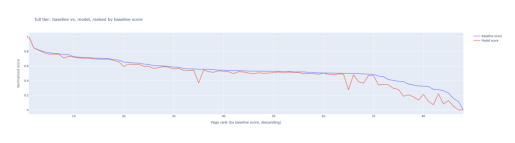

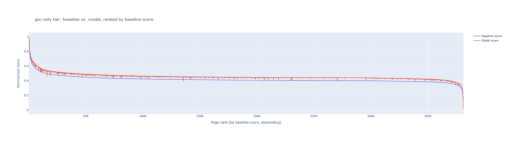

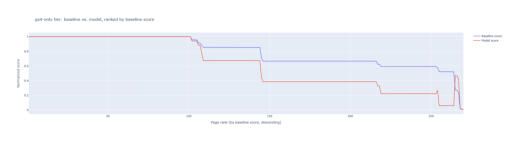

In [32]:
from PIL import Image
import matplotlib.pyplot as plt

for path in images:
    plt.Figure(figsize=(10,6))
    img = Image.open(path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.